# Random Forest surrogate and SHAP
The target is the calculated normalized J-score. A design-group holdout and GroupKFold keep all drug records sharing a microneedle configuration together. Scaling is fitted inside each pipeline/fold. Metrics describe approximation of the analytical score over held-out listed designs, not experimental or clinical delivery.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
ROOT=Path("..").resolve()
RAW=ROOT/"data/raw"; PROC=ROOT/"data/processed/final"
FIG=ROOT/"results/final/figures"; TAB=ROOT/"results/final/tables"
for p in (PROC,FIG,TAB): p.mkdir(parents=True,exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["savefig.dpi"]=300

from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit,GroupKFold,cross_val_predict
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import shap

In [2]:
df=pd.read_csv(PROC/"combined_combinations.csv")
features=["MW_g_mol","LogP","Solubility_mg_mL","pKa","Length_um","Base_size_um","Tip_diameter_um","Inner_diameter_um","Cone_radius_um","Density_cm2","Insertion_speed_mm_s","Concentration_pct"]
d=df[["Drug","Design_ID"]+features+["J_Score_Normalized"]].dropna().copy()
X=d[features]; y=d.J_Score_Normalized; groups=d.Design_ID
split=GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42)
tr,te=next(split.split(X,y,groups))
def pipe(): return make_pipeline(MinMaxScaler(),RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1))
model=pipe().fit(X.iloc[tr],y.iloc[tr]); pred=model.predict(X.iloc[te])
oof=cross_val_predict(pipe(),X,y,groups=groups,cv=GroupKFold(n_splits=5),n_jobs=1)
metrics=pd.DataFrame([["Grouped holdout R2",r2_score(y.iloc[te],pred)],["Grouped holdout MAE",mean_absolute_error(y.iloc[te],pred)],["Grouped holdout RMSE",mean_squared_error(y.iloc[te],pred)**.5],["5-fold GroupKFold OOF R2",r2_score(y,oof)],["5-fold GroupKFold OOF MAE",mean_absolute_error(y,oof)],["5-fold GroupKFold OOF RMSE",mean_squared_error(y,oof)**.5]],columns=["Metric","Value"])
metrics.to_csv(TAB/"surrogate_metrics.csv",index=False,encoding="utf-8-sig")
o=d[["Drug","Design_ID","Length_um","Base_size_um","Tip_diameter_um","Inner_diameter_um","Cone_radius_um","Density_cm2","Insertion_speed_mm_s","Concentration_pct"]].copy()
o["J_Score_Normalized_Observed"]=y.to_numpy(); o["J_Score_Normalized_OOF_Prediction"]=oof
o.to_csv(TAB/"grouped_oof_predictions.csv",index=False,encoding="utf-8-sig")
print("Design groups:",groups.nunique(),"train/test rows:",len(tr),len(te)); print(metrics.to_string(index=False))

Design groups: 144 train/test rows: 2990 754
                    Metric    Value
        Grouped holdout R2 0.999985
       Grouped holdout MAE 0.000273
      Grouped holdout RMSE 0.000864
  5-fold GroupKFold OOF R2 0.999996
 5-fold GroupKFold OOF MAE 0.000111
5-fold GroupKFold OOF RMSE 0.000381


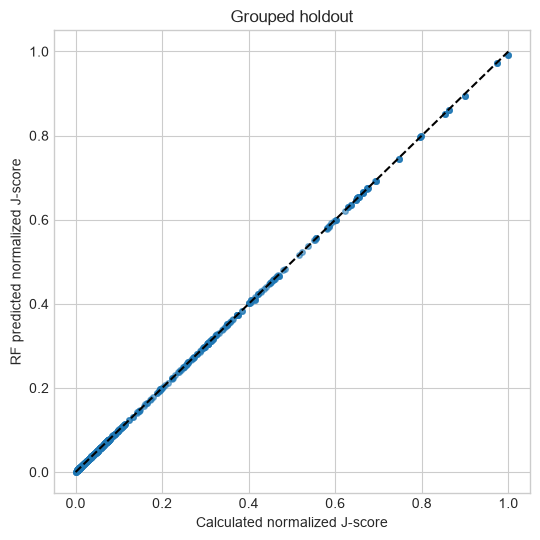

In [3]:
plt.figure(figsize=(5.5,5.5)); plt.scatter(y.iloc[te],pred,s=16,alpha=.55)
lims=[min(y.iloc[te].min(),pred.min()),max(y.iloc[te].max(),pred.max())]; plt.plot(lims,lims,"k--")
plt.xlabel("Calculated normalized J-score"); plt.ylabel("RF predicted normalized J-score"); plt.title("Grouped holdout")
plt.tight_layout(); plt.savefig(FIG/"grouped_holdout_actual_vs_predicted.png"); plt.show()

             Feature  Mean_Absolute_SHAP
   Inner_diameter_um            0.125036
         Density_cm2            0.083022
           Length_um            0.034153
            MW_g_mol            0.027349
                 pKa            0.001160
                LogP            0.000966
    Solubility_mg_mL            0.000181
     Tip_diameter_um            0.000007
        Base_size_um            0.000005
      Cone_radius_um            0.000005
Insertion_speed_mm_s            0.000000
   Concentration_pct            0.000000


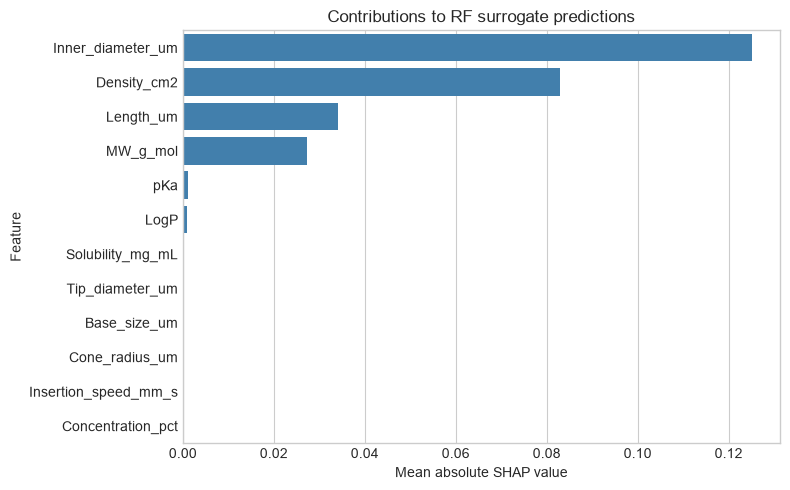

In [4]:
xe=X.iloc[te].sample(n=min(250,len(te)),random_state=42)
rf=model.named_steps["randomforestregressor"]; xs=model.named_steps["minmaxscaler"].transform(xe)
sv=shap.TreeExplainer(rf).shap_values(xs)
imp=pd.DataFrame({"Feature":features,"Mean_Absolute_SHAP":np.abs(sv).mean(axis=0)}).sort_values("Mean_Absolute_SHAP",ascending=False)
imp.to_csv(TAB/"shap_importance_ranking.csv",index=False,encoding="utf-8-sig"); print(imp.to_string(index=False))
plt.figure(figsize=(8,5)); sns.barplot(data=imp,x="Mean_Absolute_SHAP",y="Feature",color="#3182bd")
plt.xlabel("Mean absolute SHAP value"); plt.ylabel("Feature"); plt.title("Contributions to RF surrogate predictions")
plt.tight_layout(); plt.savefig(FIG/"shap_importance.png"); plt.show()

SHAP summarizes contributions to the fitted RF surrogate predictions. It does not establish causal or experimentally measured feature importance.